In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
import joblib
import ydf

## ***Load Dataset***

In [3]:
df = pd.read_csv('datasets/final_480_000_balanced_datasets.csv')

In [4]:
df.shape

(480000, 50)

In [5]:
df.head()

,url,label,whois_success,domain_age_days,creation_year,url_length,domain_length,hostname_length,path_length,tld_length,...,contains_bank,contains_crypto,contains_pay,contains_obfuscation,has_specials,is_ip_address,uses_https,has_www,unusual_double_slash,is_shortened
0,https://archive.md/https://rt.live/,0,1,0,0,35,10,10,17,2,...,0,0,0,0,1,0,1,0,1,0
1,https://qrco.de/bfJWp9,1,1,0,0,22,7,7,7,2,...,0,0,0,0,1,0,1,0,0,1
2,https://bloody-disgusting.com/movie/3915052/bl...,0,1,8680,2002,121,21,21,92,3,...,0,1,0,0,1,0,1,0,0,0
3,https://tetryueiwoppiyuqi-3kjhkwey.pages.dev/,1,1,0,0,45,9,36,1,3,...,0,0,0,0,1,0,1,0,0,0
4,https://bit.ly/3Ypgh5X,1,1,6397,2008,22,6,6,8,2,...,0,1,0,0,1,0,1,0,0,1


## ***Split Data***

In [7]:
if 'url' in df.columns:
    df = df.drop(columns=['url'])
if 'contains_login' in df.columns:
    df = df.drop(columns=['contains_login'])
if 'has_specials' in df.columns:
    df = df.drop(columns=['has_specials'])
df.head()
train_df = df.sample(frac=0.8)
test_df = df.drop(train_df.index)

true_labels = test_df["label"].values

## ***Train Random Forest***

In [8]:
rf_model = ydf.RandomForestLearner(
    label='label',
    num_trees=200,
    max_depth=6
).train(train_df)

Train model on 384000 examples
Model trained in 0:00:22.375732


In [18]:
rf_model_description = rf_model.describe()
with open("images/rf_model_description.html", "w", encoding="utf-8") as f:
    f.write(rf_model_description._html)

rf_model_description

### ***Use Random Forest For Testing***

In [19]:
rf_predictions = rf_model.predict(test_df)

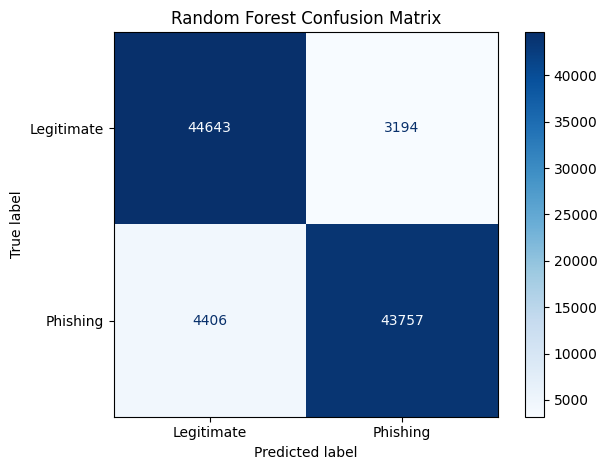

In [20]:
rf_cm = confusion_matrix(true_labels,rf_predictions.round())
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels=['Legitimate','Phishing'])
disp.plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig('images/random_forest_confusion_matrix.png')
plt.show()

## ***Save the model***

In [21]:
rf_model.save("models/random_forest_model")
joblib.dump(rf_model, "models/random_forest_model.joblib")

['models/random_forest_model.joblib']

## ***Decision Tree***

In [22]:
dt_model = ydf.DecisionTreeLearner(
    label="label",
    max_depth=6,
).train(train_df)

Train model on 384000 examples
Model trained in 0:00:02.149947


In [23]:
dt_model_description = dt_model.describe()
with open("images/dt_model_description.html", "w", encoding="utf-8") as f:
    f.write(dt_model_description._html) 

dt_model_description

## ***Use Decision Tree For Testing***

In [27]:
dt_predictions = dt_model.predict(test_df)

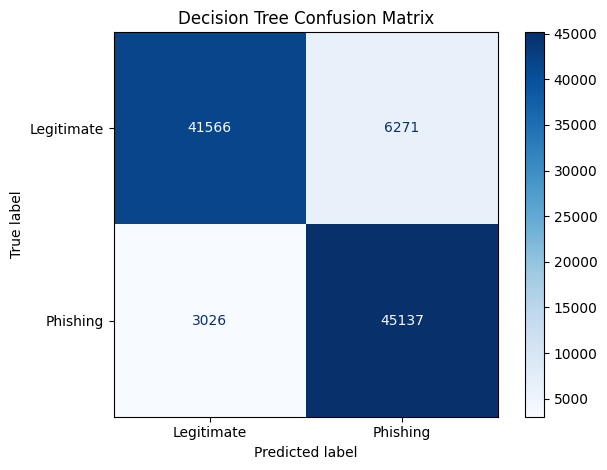

In [28]:
dt_cm = confusion_matrix(true_labels, dt_predictions.round())
disp = ConfusionMatrixDisplay(confusion_matrix=dt_cm,display_labels=['Legitimate','Phishing'])
disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.savefig('images/decision_tree_confusion_matrix.png')
plt.show()

In [29]:
rf_model.save("models/decision_tree_model")
joblib.dump(rf_model, "models/decision_tree_model.joblib")

['models/decision_tree_model.joblib']

## ***CNN Training***

In [101]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## ***Data Loading & Preprocessing***

In [96]:
df = pd.read_csv('datasets/final_480_000_balanced_datasets.csv')

In [97]:
df.head()

,url,label,whois_success,domain_age_days,creation_year,url_length,domain_length,hostname_length,path_length,tld_length,...,contains_bank,contains_crypto,contains_pay,contains_obfuscation,has_specials,is_ip_address,uses_https,has_www,unusual_double_slash,is_shortened
0,https://archive.md/https://rt.live/,0,1,0,0,35,10,10,17,2,...,0,0,0,0,1,0,1,0,1,0
1,https://qrco.de/bfJWp9,1,1,0,0,22,7,7,7,2,...,0,0,0,0,1,0,1,0,0,1
2,https://bloody-disgusting.com/movie/3915052/bl...,0,1,8680,2002,121,21,21,92,3,...,0,1,0,0,1,0,1,0,0,0
3,https://tetryueiwoppiyuqi-3kjhkwey.pages.dev/,1,1,0,0,45,9,36,1,3,...,0,0,0,0,1,0,1,0,0,0
4,https://bit.ly/3Ypgh5X,1,1,6397,2008,22,6,6,8,2,...,0,1,0,0,1,0,1,0,0,1


In [99]:
df.shape

(480000, 50)

### ***Splitting the dataset***

In [107]:
X = df.drop(['url','label','contains_login','has_specials'], axis=1)
Y = df['label']

X_train, X_test_val, Y_train, Y_test_val = train_test_split(
    X,Y, test_size=0.2, random_state=42, stratify=Y
)

X_test, X_val, Y_test, Y_val = train_test_split(
    X_test_val,Y_test_val, test_size=0.5, random_state=42, stratify=Y_test_val
)

Y_train_encoded = to_categorical(Y_train, num_classes=2)
Y_test_encoded = to_categorical(Y_test, num_classes=2)

In [108]:
X.shape

(480000, 46)

### ***Build CNN Model***

In [112]:
cnn_model = models.Sequential([
    tf.keras.Input(shape=(46,1)),
    tf.keras.layers.Conv1D(filters=64, kernel_size=2, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.LSTM(100),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation = 'sigmoid'),
    tf.keras.layers.Dense(512, activation='sigmoid'),
    tf.keras.layers.Dense(64, activation = 'sigmoid'),
    tf.keras.layers.Dense(2, activation='sigmoid'),
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

training_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True,verbose=1),
    callbacks.ModelCheckpoint(filepath='models/best_cnn_model.keras', monitor='val_loss', save_best_only=True,verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

In [113]:
cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)              │ (None, 45, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,898 (542.57 KB)

 Trainable params: 138,898 (542.57 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
cnn_history = cnn_model.fit(
    X_train,Y_train_encoded,
    validation_data = (X_test,Y_test_encoded),
    epochs=25,
    callbacks=training_callbacks
)

Epoch 1/25
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9525 - loss: 0.1271
Epoch 1: val_loss improved from 0.13495 to 0.12053, saving model to models/best_cnn_model.keras

Epoch 1: finished saving model to models/best_cnn_model.keras
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 159s 13ms/step - accuracy: 0.9530 - loss: 0.1252 - val_accuracy: 0.9554 - val_loss: 0.1205 - learning_rate: 0.0010
Epoch 2/25
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9549 - loss: 0.1191
Epoch 2: val_loss did not improve from 0.12053
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 159s 13ms/step - accuracy: 0.9556 - loss: 0.1184 - val_accuracy: 0.9542 - val_loss: 0.1232 - learning_rate: 0.0010
Epoch 3/25
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9565 - loss: 0.1167
Epoch 3: val_loss improved from 0.12053 to 0.11134, saving model to models/best_cnn_model.keras

Epoch 3: finished saving model to models/best_cnn_model.keras
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 149s 12ms/step - accuracy: 0.9572

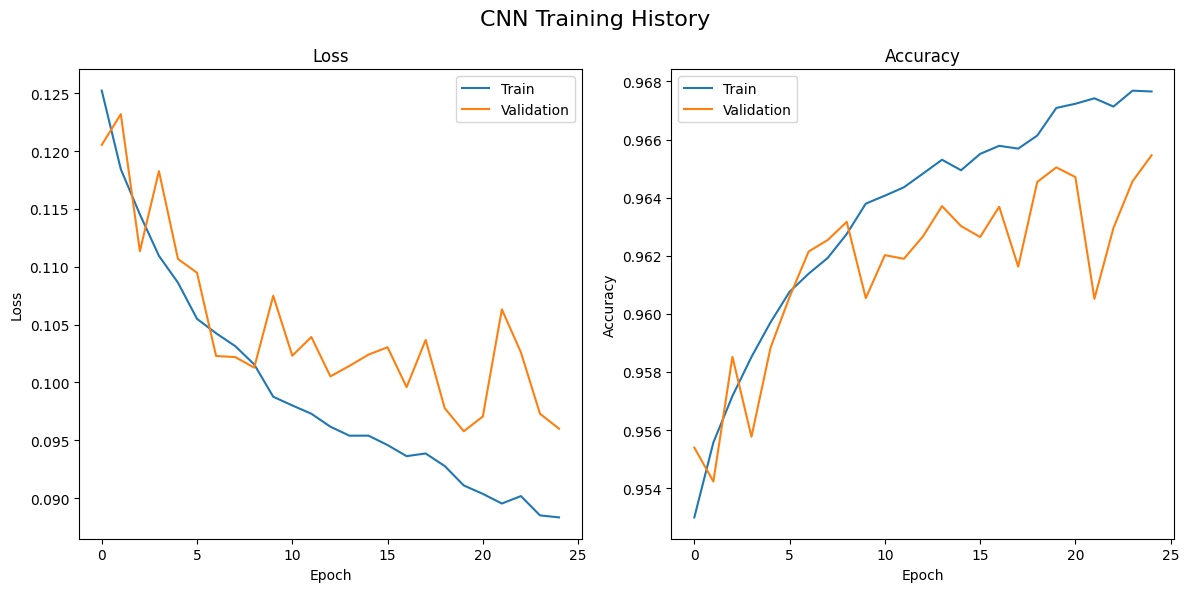

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Loss
axes[0].plot(cnn_history.history['loss'], label='Train')
axes[0].plot(cnn_history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(cnn_history.history['accuracy'], label='Train')
axes[1].plot(cnn_history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('CNN Training History', fontsize=16)
plt.tight_layout()
plt.savefig('./images/cnn_training_history.png')
plt.show()

In [121]:
cnn_model.save("./images/final_cnn_lstm.keras")
joblib.dump(rf_model, "models/cnn_model.joblib")

['models/cnn_model.joblib']

In [122]:
cnn_y_pred = cnn_model.predict(X_test)
report = classification_report(Y_test, np.argmax(cnn_y_pred, axis=1))
print(report)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     24000
           1       0.97      0.96      0.96     24000

    accuracy                           0.97     48000
   macro avg       0.97      0.97      0.97     48000
weighted avg       0.97      0.97      0.97     48000



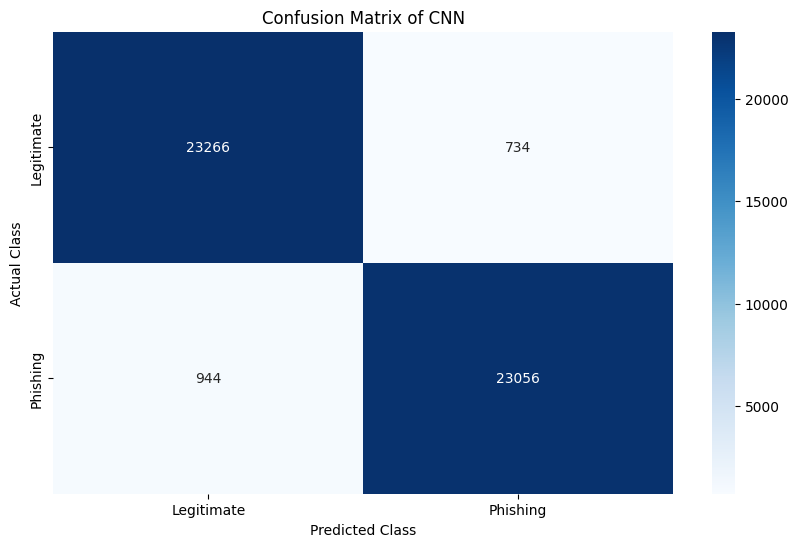

In [123]:
cnn_y_pred_classes = np.argmax(cnn_y_pred, axis=1)
cm = confusion_matrix(Y_test, cnn_y_pred_classes)
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(cm, fmt = 'd', annot=True, cmap='Blues',xticklabels=['Legitimate','Phishing'], yticklabels=['Legitimate','Phishing'])

ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')
ax.set_title('Confusion Matrix of CNN')
plt.savefig('./images/cnn_confusion_matrix.png')
plt.show()